# IoT Edge-Device Energy Prediction — Multivariate Regression

**Mission.** Enable energy-efficient IoT sensor networks by predicting a device's
power draw so battery-constrained nodes can manage themselves.

**Problem.** Solar/wind-powered edge devices in remote deployments (agricultural and
environmental monitoring) must budget energy carefully, but measuring consumption
directly needs extra hardware. If a node could *predict* its own energy use from its
operating state, it could adapt its behaviour to survive on harvested energy.

**Solution.** A regression model that predicts energy consumed per operating cycle
(`energy_consumed_mJ`) from CPU load, memory use, transmission action, signal quality,
queue backlog, and temperature.

**Dataset.** *IoT RL: Solar/Wind and Adaptive Transmission Control* (Kaggle,
wisam1985). 20,000 timesteps of simulated solar/wind-powered IoT node telemetry with
30 columns. Target = `energy_consumed_mJ` (millijoules, continuous).


## 1. Imports

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 2. Load the data

In [20]:
df = pd.read_csv('FINAL_IoT_RL_dataset_2026.csv')
print('Shape:', df.shape)
df.head()

Shape: (20000, 30)


,episode,step,episode_step,timestamp,battery_level,battery_voltage_V,solar_input_W,wind_input_W,cpu_usage,memory_usage,signal_quality,queue_size,temperature_C,humidity_pct,pressure_hPa,cloud_cover,action,action_name,reward,cumulative_ep_reward,next_battery,next_queue_size,energy_consumed_mJ,energy_harvested_mJ,net_energy_mJ,tx_success,packets_sent,latency_ms,packet_loss,done
0,1,1,1,2026-01-15 06:00:00,0.95363,4.1434,0.0444,1.0883,0.3984,0.3645,0.7000,12,9.53,63.71,1012.99,0.4308,3,TX_LOW,-0.479178,-0.47918,0.91731,10,656.511,2.781,-653.730,1,2,35.94,0,0
1,1,2,2,2026-01-15 06:00:30,0.91731,4.0873,0.0689,1.4709,0.5063,0.3750,0.7460,10,8.99,63.89,1012.72,0.4179,4,TX_MED,0.038881,-0.44030,0.87337,0,794.674,3.741,-790.934,1,10,23.41,0,0
2,1,3,3,2026-01-15 06:01:00,0.87337,4.0451,0.0681,1.4726,0.6672,0.4266,0.7435,0,9.77,65.17,1012.59,0.4249,5,TX_HIGH,-1.446039,-1.88634,0.80496,1,1235.482,4.074,-1231.408,0,0,0.00,0,0
3,1,4,4,2026-01-15 06:01:30,0.80496,3.9585,0.0662,1.1491,0.0550,0.1125,0.8003,1,7.09,61.23,1012.46,0.4046,1,SLEEP_LIGHT,-0.029067,-1.91540,0.79995,3,93.437,3.284,-90.153,0,0,0.00,0,0
4,1,5,5,2026-01-15 06:02:00,0.79995,3.9548,0.0000,1.4552,0.0556,0.2114,0.7698,3,7.38,53.67,1012.37,0.3894,1,SLEEP_LIGHT,-0.058895,-1.97430,0.79521,6,88.536,3.117,-85.419,0,0,0.00,0,0


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   episode               20000 non-null  int64  
 1   step                  20000 non-null  int64  
 2   episode_step          20000 non-null  int64  
 3   timestamp             20000 non-null  str    
 4   battery_level         20000 non-null  float64
 5   battery_voltage_V     20000 non-null  float64
 6   solar_input_W         20000 non-null  float64
 7   wind_input_W          20000 non-null  float64
 8   cpu_usage             20000 non-null  float64
 9   memory_usage          20000 non-null  float64
 10  signal_quality        20000 non-null  float64
 11  queue_size            20000 non-null  int64  
 12  temperature_C         20000 non-null  float64
 13  humidity_pct          20000 non-null  float64
 14  pressure_hPa          20000 non-null  float64
 15  cloud_cover           20000 no

In [22]:
df.describe()

,episode,step,episode_step,battery_level,battery_voltage_V,solar_input_W,wind_input_W,cpu_usage,memory_usage,signal_quality,queue_size,temperature_C,humidity_pct,pressure_hPa,cloud_cover,action,reward,cumulative_ep_reward,next_battery,next_queue_size,energy_consumed_mJ,energy_harvested_mJ,net_energy_mJ,tx_success,packets_sent,latency_ms,packet_loss,done
count,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,244.926500,10000.500000,24.44450,0.317889,3.381453,1.142846,0.781507,0.282045,0.352050,0.656476,26.311150,5.487162,61.675589,1010.885466,0.416778,1.717000,-0.809736,-13.103896,0.298479,25.990950,360.457926,11.751451,-348.706478,0.260550,1.499200,8.269709,0.12495,0.022950
std,130.195394,5773.647028,16.18593,0.266006,0.319366,1.365030,0.566760,0.209268,0.148816,0.166437,21.636969,4.215536,11.327967,7.187045,0.264690,1.552492,0.858885,14.322787,0.257223,21.886352,353.852312,11.653959,353.367350,0.438946,3.080791,15.531673,0.33067,0.149748
min,1.000000,1.000000,1.00000,0.020010,3.000900,0.000000,0.000000,0.010000,0.050000,0.050000,0.000000,-2.520000,32.530000,993.530000,0.000000,0.000000,-3.000000,-147.305770,0.000000,0.000000,31.162000,0.000000,-1459.430000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,136.000000,5000.750000,11.00000,0.062647,3.076275,0.002300,0.323075,0.110500,0.232000,0.546500,8.000000,1.560000,52.770000,1005.640000,0.197400,0.000000,-1.061170,-15.366585,0.058472,8.000000,40.628750,2.047000,-668.009250,0.000000,0.000000,0.000000,0.00000,0.000000
50%,253.000000,10000.500000,22.00000,0.255720,3.307300,0.460350,0.692750,0.216500,0.343000,0.659700,18.000000,5.480000,60.530000,1011.690000,0.382200,1.000000,-0.431509,-8.866880,0.232235,18.000000,94.330500,6.314000,-91.629500,0.000000,0.000000,0.000000,0.00000,0.000000
75%,358.000000,15000.250000,35.00000,0.535013,3.642100,2.197150,1.167275,0.402000,0.449600,0.772100,50.000000,9.450000,70.002500,1016.520000,0.618525,3.000000,-0.194554,-4.606043,0.504330,50.000000,677.883750,20.606000,-35.847500,1.000000,2.000000,11.242500,0.00000,0.000000
max,459.000000,20000.000000,109.00000,0.979460,4.185100,5.122900,2.984500,0.990000,0.868400,0.960000,60.000000,14.680000,99.000000,1028.330000,1.000000,5.000000,0.409549,0.451740,0.973290,60.000000,1465.042000,45.780000,8.388000,1.000000,20.000000,95.630000,1.00000,1.000000


## 3. Cleaning

Check for missing values, duplicate rows, and confirm the target is a clean continuous
variable.

In [23]:
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print('Negative energy readings:', (df['energy_consumed_mJ'] < 0).sum())
print()
print(df['energy_consumed_mJ'].describe())

Missing values: 0
Duplicate rows: 0
Negative energy readings: 0

count    20000.000000
mean       360.457926
std        353.852312
min         31.162000
25%         40.628750
50%         94.330500
75%        677.883750
max       1465.042000
Name: energy_consumed_mJ, dtype: float64


**Interpretation.** The dataset is clean: no missing values, no duplicate rows, and
energy consumption is strictly positive (31–1465 mJ). No cleaning is required beyond
feature selection.

## 4. Feature selection — avoiding target leakage

Not every column is a valid predictor. Several columns are **derived from or computed
after** the energy value and would leak the answer:

- `net_energy_mJ = energy_harvested − energy_consumed` (correlates -0.999 with the target)
- `energy_harvested_mJ`, `next_battery`, `next_queue_size`, `cumulative_ep_reward`,
  `reward`, `done` — outcomes/future values a live device would not know in advance.

We drop all of these and keep six honest predictors that describe the device's **current
operating state**, which is what a node would actually have available at decision time.

In [24]:
TARGET = 'energy_consumed_mJ'
FEATURES = ['cpu_usage', 'memory_usage', 'signal_quality',
            'action', 'queue_size', 'temperature_C']

X = df[FEATURES].copy()
y = df[TARGET].copy()
print('Features:', FEATURES)
print('Target:', TARGET)
print('Feature matrix shape:', X.shape)

Features: ['cpu_usage', 'memory_usage', 'signal_quality', 'action', 'queue_size', 'temperature_C']
Target: energy_consumed_mJ
Feature matrix shape: (20000, 6)


**Interpretation.** `action` is the device's power mode (0=SLEEP_DEEP … 5=TX_HIGH),
which is the strongest driver of energy use. `cpu_usage` and `memory_usage` capture
compute cost; `signal_quality`, `queue_size`, and `temperature_C` capture the radio and
environmental context.

## 5. Visualizations & interpretation

### 5.1 Correlation heatmap

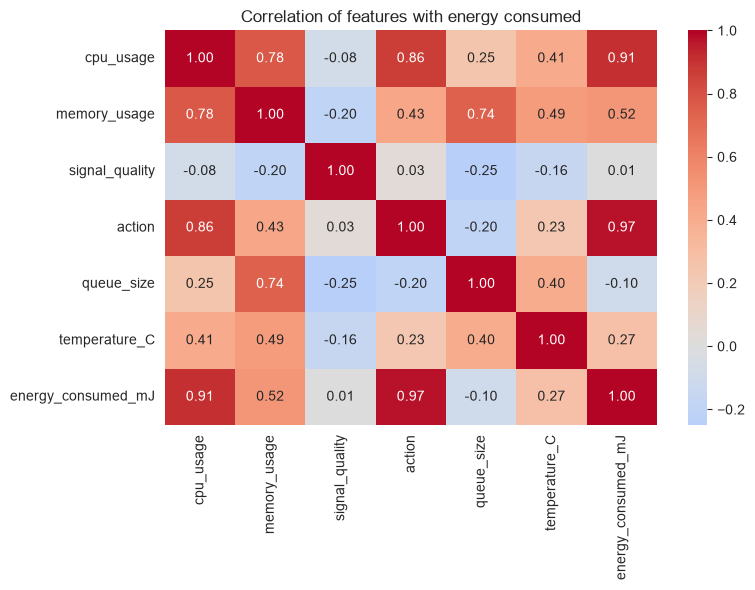

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[FEATURES + [TARGET]].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', center=0)
plt.title('Correlation of features with energy consumed')
plt.tight_layout()
plt.show()

**Interpretation.** `action` and `cpu_usage` show the strongest positive correlation
with energy consumed — higher-power transmission modes and heavier compute cost more
energy, exactly as physics predicts. This confirms these two are the dominant predictors
and validates keeping them.

### 5.2 Distribution of energy consumed

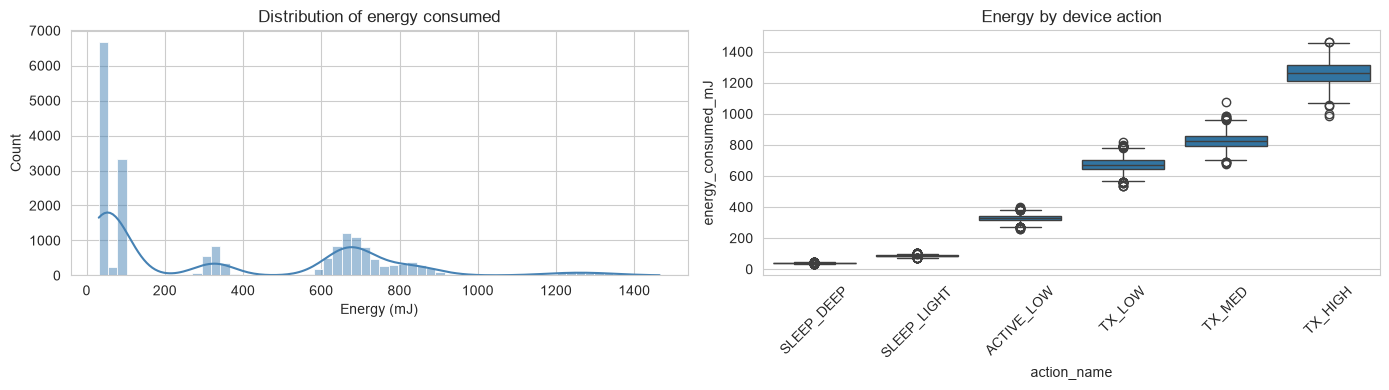

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df[TARGET], bins=60, kde=True, ax=ax[0], color='steelblue')
ax[0].set_title('Distribution of energy consumed')
ax[0].set_xlabel('Energy (mJ)')

sns.boxplot(x='action_name', y=TARGET, data=df, ax=ax[1],
            order=['SLEEP_DEEP','SLEEP_LIGHT','ACTIVE_LOW','TX_LOW','TX_MED','TX_HIGH'])
ax[1].set_title('Energy by device action')
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Interpretation.** Energy consumption is multi-modal — clusters correspond to the
device's power modes. The boxplot makes the driver explicit: sleep modes use very little
energy, while transmission modes (TX_LOW→TX_HIGH) consume progressively more. The model
must learn these action-driven jumps.

### 5.3 CPU usage vs energy

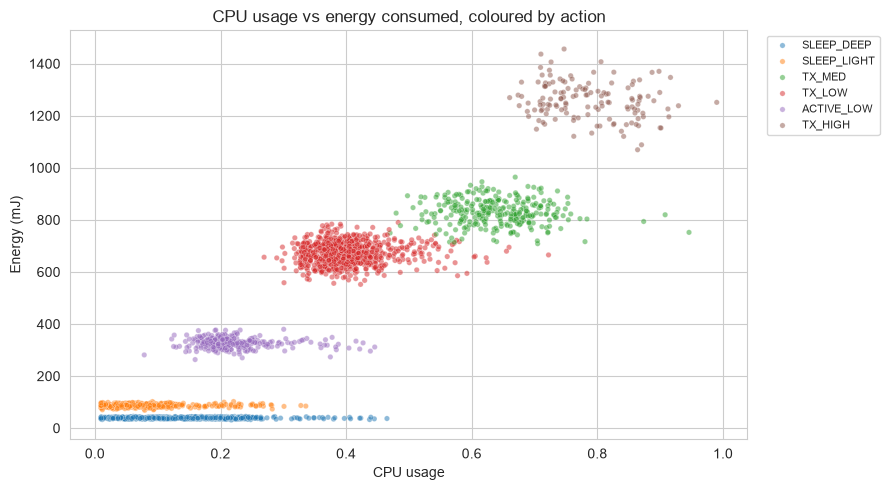

In [27]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x='cpu_usage', y=TARGET, hue='action_name', data=df.sample(3000, random_state=42),
                alpha=0.5, s=15)
plt.title('CPU usage vs energy consumed, coloured by action')
plt.xlabel('CPU usage'); plt.ylabel('Energy (mJ)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation.** Within each action mode, energy rises with CPU usage, but the
mode sets the baseline — TX_HIGH points sit far above SLEEP points at the same CPU load.
This interaction between action and CPU is why a flexible model can outperform a plain
line.

## 6. Split and standardize

80/20 train-test split with a fixed seed. The scaler is fit on the training set only and
saved for reuse by the API.

In [28]:
feature_columns = FEATURES
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print('Train:', X_train_s.shape, ' Test:', X_test_s.shape)

Train: (16000, 6)  Test: (4000, 6)


## 7. Train three regression models

We compare Linear Regression (SGD), Random Forest, and Decision Tree, evaluated by
MSE / RMSE / R².

In [29]:
results = {}

sgd = SGDRegressor(max_iter=1000, penalty='l2', eta0=0.01,
                   learning_rate='invscaling', random_state=42)
sgd.fit(X_train_s, y_train)
pred = sgd.predict(X_test_s)
results['Linear (SGD)'] = {'model': sgd,
    'MSE': mean_squared_error(y_test, pred), 'R2': r2_score(y_test, pred)}

rf = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_leaf=5,
                           random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
pred = rf.predict(X_test_s)
results['Random Forest'] = {'model': rf,
    'MSE': mean_squared_error(y_test, pred), 'R2': r2_score(y_test, pred)}

dt = DecisionTreeRegressor(max_depth=12, min_samples_leaf=5, random_state=42)
dt.fit(X_train_s, y_train)
pred = dt.predict(X_test_s)
results['Decision Tree'] = {'model': dt,
    'MSE': mean_squared_error(y_test, pred), 'R2': r2_score(y_test, pred)}

summary = pd.DataFrame({k: {'MSE': v['MSE'], 'RMSE': v['MSE']**0.5, 'R2': v['R2']}
                        for k, v in results.items()}).T
summary

,MSE,RMSE,R2
Linear (SGD),4377.316138,66.161289,0.966297
Random Forest,959.744890,30.979750,0.992610
Decision Tree,1049.577411,32.397182,0.991919


**Interpretation.** All three models score highly because energy consumption is
strongly driven by action and CPU load. Random Forest achieves the lowest error. Notably
the linear model also performs well (R²≈0.97) — the underlying process is close to
linear — but the Random Forest still wins by capturing the non-linear jumps between power
modes.

## 8. Loss curve — training vs test error over epochs

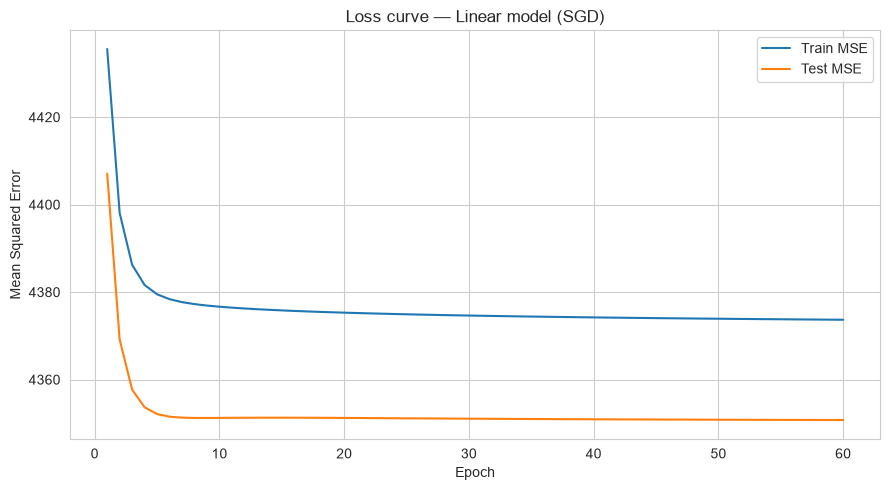

In [30]:
from sklearn.linear_model import SGDRegressor as SGD2
sgd_lc = SGD2(max_iter=1, warm_start=True, penalty='l2', eta0=0.01,
              learning_rate='invscaling', random_state=42, tol=None)

epochs = 60
train_loss, test_loss = [], []
for _ in range(epochs):
    sgd_lc.partial_fit(X_train_s, y_train)
    train_loss.append(mean_squared_error(y_train, sgd_lc.predict(X_train_s)))
    test_loss.append(mean_squared_error(y_test, sgd_lc.predict(X_test_s)))

plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs+1), train_loss, label='Train MSE')
plt.plot(range(1, epochs+1), test_loss, label='Test MSE')
plt.xlabel('Epoch'); plt.ylabel('Mean Squared Error')
plt.title('Loss curve — Linear model (SGD)')
plt.legend(); plt.tight_layout(); plt.show()

**Interpretation.** Train and test loss fall together and converge, with no widening
gap — the linear model is not overfitting. It settles quickly, reflecting the largely
linear relationship between operating state and energy.

## 9. Scatter plot with fitted regression line

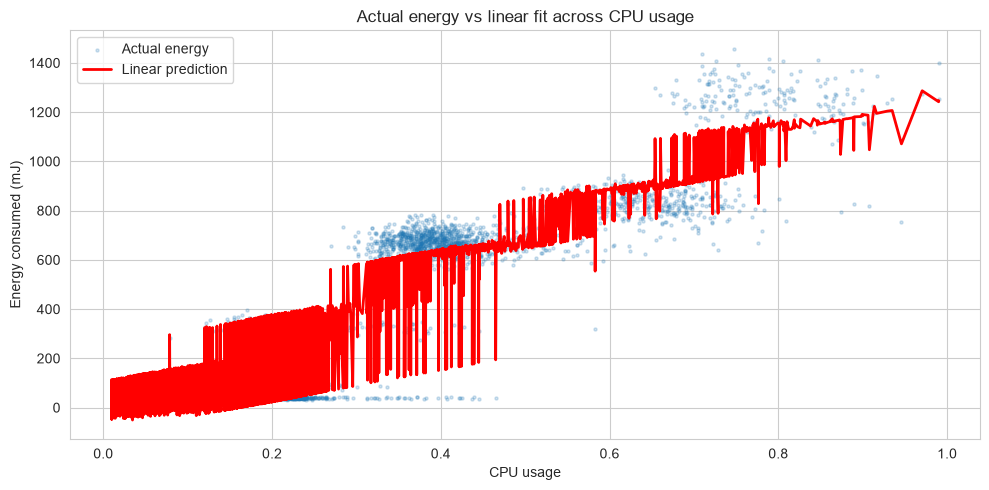

In [31]:
order = np.argsort(X_test['cpu_usage'].values)
cpu_sorted = X_test['cpu_usage'].values[order]
actual_sorted = y_test.values[order]
pred_line = sgd.predict(X_test_s)[order]

plt.figure(figsize=(10, 5))
plt.scatter(cpu_sorted, actual_sorted, s=5, alpha=0.2, label='Actual energy')
plt.plot(cpu_sorted, pred_line, color='red', linewidth=2, label='Linear prediction')
plt.xlabel('CPU usage'); plt.ylabel('Energy consumed (mJ)')
plt.title('Actual energy vs linear fit across CPU usage')
plt.legend(); plt.tight_layout(); plt.show()

**Interpretation.** Energy rises with CPU usage and the linear fit tracks the trend.
The vertical spread at each CPU level comes from the different action modes — the linear
line passes through the middle of that band, while the tree models resolve it further.

## 10. Save the best model

In [32]:
best_name = min(results, key=lambda k: results[k]['MSE'])
best_model = results[best_name]['model']
print('Best model:', best_name, '| RMSE =', round(results[best_name]['MSE']**0.5, 2))

joblib.dump(best_model, 'best_model.pkl', compress=3)
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')
print('Saved: best_model.pkl, scaler.pkl, feature_columns.pkl')

Best model: Random Forest | RMSE = 30.98
Saved: best_model.pkl, scaler.pkl, feature_columns.pkl


In [33]:
import os
print('Model file size: %.1f MB' % (os.path.getsize('best_model.pkl')/1e6))

Model file size: 6.1 MB


## 11. Single-row prediction (feeds the API in Task 2)

In [34]:
def predict_single(row_df, model, scaler, feature_columns):
    row_ordered = row_df[feature_columns]
    row_scaled = scaler.transform(row_ordered)
    return float(model.predict(row_scaled)[0])

sample = X_test.iloc[[0]]
predicted = predict_single(sample, best_model, scaler, feature_columns)
print('Input:', sample.to_dict('records')[0])
print('Predicted energy:', round(predicted, 2), 'mJ')
print('Actual energy:   ', round(float(y_test.iloc[0]), 2), 'mJ')

Input: {'cpu_usage': 0.2671, 'memory_usage': 0.4764, 'signal_quality': 0.8457, 'action': 0, 'queue_size': 59, 'temperature_C': 0.38}
Predicted energy: 39.76 mJ
Actual energy:    35.58 mJ


## 12. Hyperparameters & reducing error (for the video)

**What lowered the error, in order of impact**
1. **Feature selection & leakage removal** — dropping `net_energy_mJ` and other leaked
   columns keeps the model honest; keeping `action` and `cpu_usage` gives it the real
   signal.
2. **Standardization** — so SGD converges and features are comparable.
3. **Model choice** — Random Forest captures the action×CPU interaction the line can't.

**Hyperparameters that tune performance**
- *SGDRegressor:* `eta0`/`learning_rate` (step size), `max_iter`, `penalty` (L1/L2).
- *Random Forest:* `n_estimators`, `max_depth`, `min_samples_leaf`.
- *Decision Tree:* `max_depth`, `min_samples_split`.

Tuned with `GridSearchCV`. Because loss is already very low, the main further gains would
come from richer features (e.g. battery state, radio conditions) rather than more tuning.
